# Simple Multimodal RAG
- 이미지를 텍스트로 검색/생성 하는 RAG

In [ ]:
%pip install langchain langchain-openai langchain-chroma

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
BASE_PATH = 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag'

## 이미지 캡셔닝

In [3]:
# 이미지 변환 (base64)
import base64 

def image_to_base64(image_path):
    with open(image_path, 'rb') as f:
        encoded = base64.b64encode(f.read()).decode('utf-8')
        return encoded 
    
image_to_base64(f'{BASE_PATH}/figures/figure-07.png')

'...'

In [4]:
from openai import OpenAI

client = OpenAI()

system_prompt = """
아래 이미지를 안전교육 및 화재대비 관점에서 주제문구와 각 장면에 대해 주요정보를 손실없이 한국어로 요약해주세요.
"""

def summarize_image(image_path):
    image_base64 = image_to_base64(image_path)

    response = client.responses.create(
        model='gpt-4.1',
        input=[
            {
                "role" : "system",
                "content" : [
                    {
                        "type" : "input_text",
                        "text" : system_prompt
                    }
                ]
            },
            {
                "role" : "user",
                "content" : [
                    {
                        "type" : "input_image",
                        "image_url" : f'data:image/png;base64,{image_base64}'
                    }
                ]
            }
        ]
    )

    return response.output_text 

summarize_image(f'{BASE_PATH}/figures/figure-07.png')

'### 주제 문구:\n**불을 끌 것인지 대피할 것인지 판단합니다.**\n\n### 각 장면 요약 (주요 정보 포함):\n\n1. **비상구 활용:**  \n   불길이 작거나 초기 화재 시, 비상구를 활용하여 신속하게 대피합니다.\n\n2. **완강기 활용:**  \n   화재가 커져 대피가 필요한 경우, 완강기(로프 등)나 기타 구조용 장비를 사용해 안전하게 내려갑니다.\n\n3. **경량칸막이 활용:**  \n   세대 간 경량칸막이를 이용해 옆집으로 이동하는 등 새로운 대피 경로를 활용합니다.\n\n4. **실내대피공간 활용:**  \n   불길이 막혀 있거나 외부로 나가기 어려울 땐 실내 대피공간에 머물며 구조를 기다립니다.\n\n---\n각 장면은 화재 상황에서 대피 및 안전 확보를 위한 다양한 방법(비상구, 완강기, 경량칸막이, 실내대피공간 활용)을 보여주고 있습니다.'

## Vector DB 저장

In [7]:
from langchain_chroma.vectorstores import Chroma 
from langchain_openai import OpenAIEmbeddings
from tqdm import tqdm 

persistent_directory = f'{BASE_PATH}/chroma'
embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
vectordb = Chroma(
    collection_name='multimodal_rag',
    embedding_function=embeddings,
    persist_directory=persistent_directory
)

vectordb

In [8]:
# 이미지 로드
import os

figures_dir = os.path.join(BASE_PATH, 'figures')
fig_images = [
    os.path.join(figures_dir, f)
        for f in os.listdir(figures_dir)
            if f.lower().endswith('.png')
]
fig_images = sorted(fig_images)
fig_images

['C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-01.png',
 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-02.png',
 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-03.png',
 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-04.png',
 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-05.png',
 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-06.png',
 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-07.png',
 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-08.png',
 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-09.png',
 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-10.png',
 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-11.png',
 'C:/workspaces2/09_d

In [9]:
# 이미지 캡셔닝 -> vector db 저장
for fig_img_path in tqdm(fig_images):
    b64 = image_to_base64(fig_img_path)
    summary = summarize_image(fig_img_path)
    vectordb.add_texts(
        texts=[summary],
        metadatas=[
            {'base64_image' : b64, 'image_path' : fig_img_path}
        ]
    )

100%|██████████| 15/15 [01:13<00:00,  4.87s/it]


In [10]:
docs = vectordb._collection.get()
docs

{'ids': ['5948cae1-de0c-4bb3-85f9-c0ca35b95285',
  '526593f0-db71-4f02-8674-7b526a52dc40',
  '1fb75c1a-6c10-4684-90cc-bcc552ea5d36',
  '7bfde941-d0d2-47a1-acf0-70e4b3bc09c7',
  '758bc868-2634-4787-9be1-48e3ecbaa8aa',
  '28caa369-9d9c-4a29-9bca-8ed5c7d75258',
  '33c0d89d-982c-4574-8d0b-ef6c1ca34448',
  'c1a86b60-67df-46c9-b0a8-72d0ec203343',
  'ebaf7fab-2913-4eaf-8060-dd3a31ac0d83',
  'bd77ea06-48aa-49e4-84ff-f26ab083605d',
  'fbc9ecd6-3e25-4d2f-9290-2d77d4d4bb2b',
  '134ff468-adc1-4035-bba5-b712321a8f57',
  '15ef19cf-d38a-4726-8844-b3b3da54fab7',
  '3b7e7e6b-9d72-4a70-b3b7-733afc28112e',
  '64bc4ecc-0157-4afd-8c94-19d250601678'],
 'embeddings': None,
 'documents': ['### 주제 문구 요약\n**비상소집을 합니다.**\n\n### 각 장면별 주요 정보 요약\n- **이미지 설명:** 집 안에서 화재경보기가 울리는 상황에 가족들이 신속하게 한 곳에 모여 밖으로 대피하고 있음.\n- **주요 행동:** \n  - 자고 있을 때 화재경보가 울리면 불이 났는지 직접 확인하기 전에 일단 소리를 질러 모든 가족(사람들)을 깨움.\n  - 가족들이 한 곳에 모인 후, 미리 정해둔 대처방안에 따라 즉시 밖으로 대피함.\n  \n### 안전교육·화재대비 관점 요약\n- 화재경보가 울리면 바로 행동에 옮겨야 하며, 확인하려고 지체하지 말고 신속히 모두를 깨

In [12]:
for idx, (doc, meta) in enumerate(zip(docs['documents'], docs['metadatas'])):
    print(f'[{idx + 1}]')
    print('summary : ', doc)
    print('metadata.image_path', meta['image_path'])
    print('metadata.base64_image len', len(meta['base64_image']))
    print()

[1]
summary :  ### 주제 문구 요약
**비상소집을 합니다.**

### 각 장면별 주요 정보 요약
- **이미지 설명:** 집 안에서 화재경보기가 울리는 상황에 가족들이 신속하게 한 곳에 모여 밖으로 대피하고 있음.
- **주요 행동:** 
  - 자고 있을 때 화재경보가 울리면 불이 났는지 직접 확인하기 전에 일단 소리를 질러 모든 가족(사람들)을 깨움.
  - 가족들이 한 곳에 모인 후, 미리 정해둔 대처방안에 따라 즉시 밖으로 대피함.
  
### 안전교육·화재대비 관점 요약
- 화재경보가 울리면 바로 행동에 옮겨야 하며, 확인하려고 지체하지 말고 신속히 모두를 깨운 후 약속된 방법으로 빠르게 대피하는 것이 중요함.
metadata.image_path C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\figures\figure-01.png
metadata.base64_image len 65220

[2]
summary :  ### 주제 문구
**"대피방법을 결정합니다."**

### 장면별 주요 정보 요약

1. **출입문 손잡이 확인**  
   - 피난 전 손 등으로 출입문 손잡이를 만져봅니다.
   - 손잡이가 따뜻하거나 뜨거우면 문 반대편에 불이 난 것이므로 문을 열지 않습니다.

2. **경고문(대피금지) 확인 및 판단**  
   - 문에 "경고: 대피금지" 안내문 등이 있으면 주의 깊게 확인합니다.

3. **연기와 방향 확인 후 안전한 경로 선택**  
   - 연기가 들어오는 방향과 출입문 손잡이를 다시 확인합니다.
   - 상황이 위험하면 계단이나 창문 등 다른 경로로 대피하거나 구조를 요청할 수 있습니다.

### 핵심 내용 요약 (화재 대비 관점)
- 출입문이 위험할 시 반드시 손잡이 온도를 확인 후 대피 방향을 결정하며,
- 연기나 불길이 있는 쪽의 문은 열지 않고, 상황에 따라 안전한 계단이나 창문 등 대피 경로나 구조 요청을 신속히 결정해야 합니다.
met

## Retrieval


[TOP-1] 요약 : **주제 문구:**  
화재 발생 시 신속한 대피와 초기 진화, 안전 확보를 위해 우리 주변에 설치된 주요 소방시설에 대해 이해하고 점검하는 것이 중요합니다.

**주요 장면별 요약:**  
1. **제연설비:**  
화재 시 연기를 효과적으로 배출하여 대피로를 확보하고, 연기 흡입에 의한 인명 피해를 줄이는 역할을 합니다.

2. **화재감지기:**  
화재 발생 시 연기나 열을 감지하여 경보음을 울려 주변에 위험 신호를 신속히 알려줍니다.

3. **스프링클러:**  
화재 시 자동으로 물을 뿌려 화재를 진압 혹은 확산을 방지하는 자동 소화설비입니다.

4. **주방용자동소화기:**  
주방에서 조리 중 발생하는 화재를 신속하게 감지하고 자동으로 소화해 주방 화재를 초기에 진압합니다.

**종합 안내:**  
각 소방시설은 화재 예방과 피해 최소화를 위해 생활 공간 가까이에 설치되어 있으며, 정기적인 점검과 유지관리가 필수적입니다.


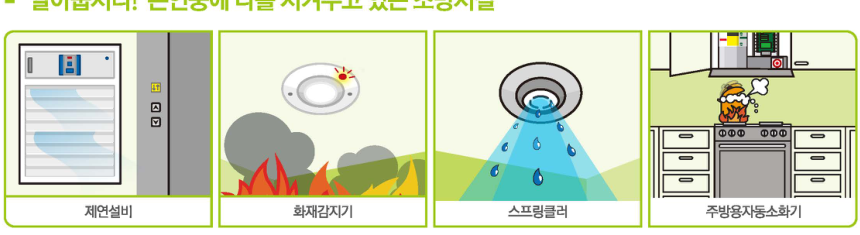


[TOP-2] 요약 : ### 주제 문구
**"대피방법을 결정합니다."**

### 장면별 주요 정보 요약

1. **출입문 손잡이 확인**  
   - 피난 전 손 등으로 출입문 손잡이를 만져봅니다.
   - 손잡이가 따뜻하거나 뜨거우면 문 반대편에 불이 난 것이므로 문을 열지 않습니다.

2. **경고문(대피금지) 확인 및 판단**  
   - 문에 "경고: 대피금지" 안내문 등이 있으면 주의 깊게 확인합니다.

3. **연기와 방향 확인 후 안전한 경로 선택**  
   - 연기가 들어오는 방향과 출입문 손잡이를 다시 확인합니다.
   - 상황이 위험하면 계단이나 창문 등 다른 경로로 대피하거나 구조를 요청할 수 있습니다.

### 핵심 내용 요약 (화재 대비 관점)
- 출입문이 위험할 시 반드시 손잡이 온도를 확인 후 대피 방향을 결정하며,
- 연기나 불길이 있는 쪽의 문은 열지 않고, 상황에 따라 안전한 계단이나 창문 등 대피 경로나 구조 요청을 신속히 결정해야 합니다.


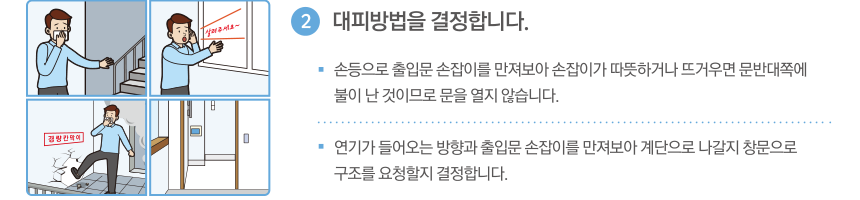

In [15]:
from io import BytesIO
from PIL import Image

def show_base64_image(b64_str):
    img = Image.open(BytesIO(base64.b64decode(b64_str)))
    display(img)

def search_and_show(query, k=2):
    docs = vectordb.similarity_search(query, k=k)

    for i, doc in enumerate(docs):
        print(f'\n[TOP-{i+1}] 요약 : {doc.page_content}')
        show_base64_image(doc.metadata['base64_image'])

query = '화재대피'

search_and_show(query)

## RetrievalQA (retrieval + generation)

In [16]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

llm = ChatOpenAI(model='gpt-4.1', temperature=0)

retriever = vectordb.as_retriever(search_kwargs={"k":2})

system_prompt = """
당신은 안전교육 및 화재대비 자료를 바탕으로 질문에 답변하는 도우미입니다.

아래 context에 포함된 내용만 근거로 답변하세요.
context에 없는 내용은 추측하지 말고, 자료에서 확인되지 않는다고 답변하세요.

답변은 한국어로 작성하세요.

<context>
{context}
</context>
"""

prompt = ChatPromptTemplate.from_messages(
    [
        ('system', system_prompt),
        ('human', '{input}')
    ]
)

question_answer_chain = create_stuff_documents_chain(
    llm=llm,
    prompt=prompt
)

rag_chain = create_retrieval_chain(
    retriever,
    question_answer_chain
)

query = "화재 시 소화기 사용법이 궁금해"

result = rag_chain.invoke(
    {'input' : query}
)

print(result)
print(result['answer'])

{'input': '화재 시 소화기 사용법이 궁금해', 'context': [Document(id='bd77ea06-48aa-49e4-84ff-f26ab083605d', metadata={'image_path': 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_rag\\figures\\figure-10.png', 'base64_image': '...'}, page_content='**주제 문구**  \n소화전 사용법\n\n**주요 정보 요약(각 장면별)**\n\n1. **문을 연다**  \n   - 소화전함의 문을 연다. (첫 번째로 해야 할 단계)\n\n2. **호스를 빼고 노즐을 잡는다**  \n   - 호스를 밖으로 꺼내 불이 난 곳까지 길게 늘인 후, 노즐(관창)을 잡는다.\n\n3. **밸브를 돌린다**  \n   - 밸브를 돌려 물이 나오는지 확인한다.\n\n4. **불을 향해 쏜다**  \n   - 방수자세를 취하고, 호스의 노즐을 잡고 불을 향해 분사한다.\n\n**추가 안내(2인 1조 사용 원칙)**  \n- 한 명은 소화전함 문을 열고 호스와 노즐의 연결 상태를 확인한다.  \n- 다른 한 명은 밸브를 돌리고, 호스가 꼬이지 않게 길게 늘여서 불이 난 곳까지 운반한다.  \n- 화재 시 호스를 불 방향으로 향하게 하고, 방수 자세를 유지한다.\n\n**안전교육 및 화재대비 관점 요약**  \n- 소화전을 사용할 때는 반드시 2인 1조로 신속하고 안전하게 움직일 것  \n- 호스와 밸브, 노즐의 상태 점검 및 꼬임 방지와 같은 기본적인 조치 지시  \n- 불을 향해 정확하게 물을 쏘도록 안내  \n- 실전 상황에서 침착하게 대응하는 행동지침 명시'), Document(id='ebaf7fab-2913-4eaf-8060-dd3a31ac0d83', metadata={'image_path': 'C:/workspaces2/09_deep_learning_multimodal/05_multimodal_r

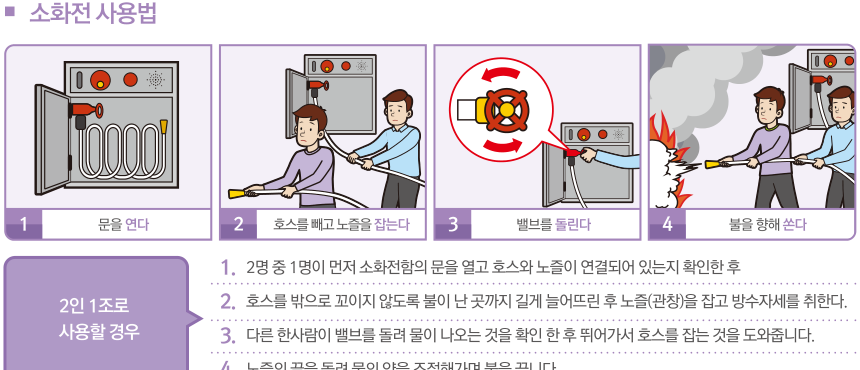

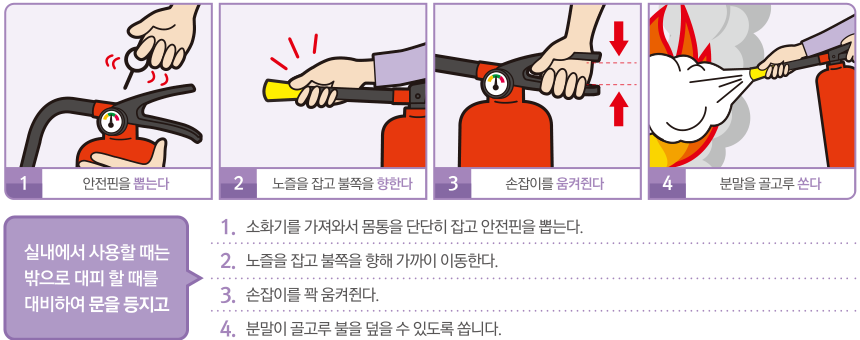

In [17]:
for doc in result['context']:
    show_base64_image(doc.metadata['base64_image'])
    